In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,classification_report,roc_auc_score,confusion_matrix
import shap

In [43]:
df = pd.read_csv("../data/processed/cleaned_retail.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 361461 entries, 0 to 361460
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   invoiceno    361461 non-null  int64  
 1   stockcode    361461 non-null  object 
 2   description  361461 non-null  object 
 3   quantity     361461 non-null  int64  
 4   invoicedate  361461 non-null  object 
 5   unitprice    361461 non-null  float64
 6   customerid   361461 non-null  float64
 7   country      361461 non-null  object 
 8   revenue      361461 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 24.8+ MB


In [4]:
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

In [8]:
latest_date = df['invoicedate'].max()

In [9]:
customer_last_purchase = df.groupby('customerid')['invoicedate'].max().reset_index()

In [10]:
customer_last_purchase['days_inactive'] = (latest_date - customer_last_purchase['invoicedate']).dt.days

In [11]:
customer_last_purchase['churn'] = (customer_last_purchase['days_inactive'] > 90).astype(int)

In [66]:
features = df.groupby('customerid').agg({
    'revenue': ['sum', 'mean', 'max', 'min'],
    'quantity': ['sum', 'mean'],
    'invoiceno': 'count'
})

In [67]:
features.columns = [
    'total_revenue',
    'avg_revenue',
    'max_revenue',
    'min_revenue',
    'total_quantity',
    'avg_quantity',
    'purchase_frequency'
]

In [69]:
features['avg_order_value'] = (features['total_revenue'] / features['purchase_frequency'])

In [71]:
features = features.reset_index()

In [72]:
churn_df = features.merge(customer_last_purchase[['customerid', 'churn']],on='customerid')

In [73]:
churn_df.head()

,customerid,total_revenue,avg_revenue,max_revenue,min_revenue,total_quantity,avg_quantity,purchase_frequency,avg_order_value,churn
0,12347.0,3174.62,18.896548,39.60,5.04,1948,11.595238,168,18.896548,0
1,12348.0,601.64,31.665263,41.76,13.20,1271,66.894737,19,31.665263,0
2,12349.0,1145.35,17.353788,39.95,6.64,530,8.030303,66,17.353788,0
3,12350.0,334.40,19.670588,40.00,8.50,197,11.588235,17,19.670588,1
4,12352.0,1505.74,18.821750,40.00,9.90,529,6.612500,80,18.821750,0


In [74]:
X = churn_df.drop(['customerid', 'churn'],axis=1)
y = churn_df['churn']

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [89]:
model = XGBClassifier(n_estimators=100,max_depth=5,learning_rate=0.1,random_state=42)

In [90]:
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [91]:
y_pred = model.predict(X_test)

In [92]:
y_prob = model.predict_proba(X_test)[:,1]

In [93]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.700834326579261


In [94]:
auc = roc_auc_score(y_test, y_prob)
print("AUC ROC:", auc)

AUC ROC: 0.7472126822955553


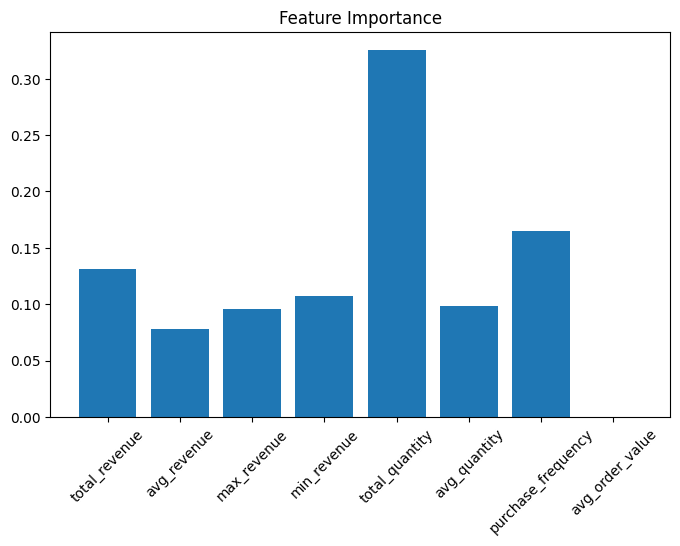

In [95]:
importance = model.feature_importances_

feature_names = X.columns
plt.figure(figsize=(8,5))

plt.bar(feature_names, importance)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()

In [96]:
joblib.dump(model,"../models/xgboost_churn.pkl")

['../models/xgboost_churn.pkl']

In [97]:
churn_results = X_test.copy()
churn_results['actual'] = y_test.values
churn_results['predicted'] = y_pred
churn_results['churn_probability'] = y_prob

In [98]:
churn_results.to_csv("../data/processed/churn_predictions.csv",index=False)

In [102]:
explainer = shap.Explainer(model.predict,X_test)

In [103]:
shap_values = explainer(X_test)

ExactExplainer explainer: 840it [00:50, 16.63it/s]                             


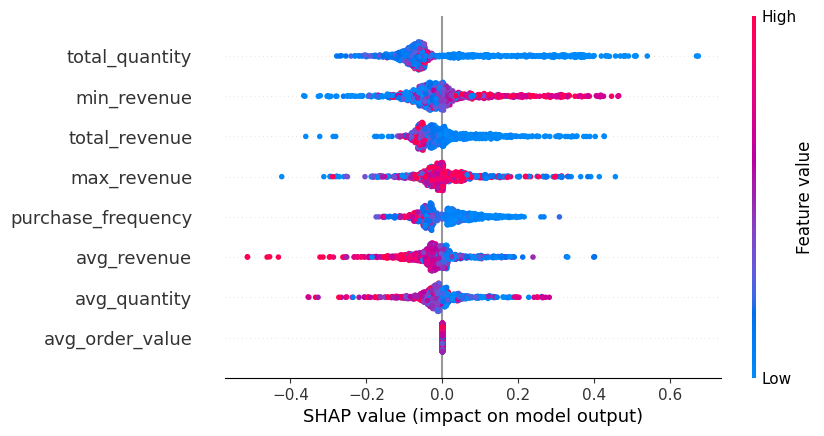

In [104]:
shap.plots.beeswarm(shap_values)

In [106]:
import mlflow

mlflow.set_experiment("RetailPulse_Churn")
with mlflow.start_run(run_name="XGBoost_Churn_Model"):

    mlflow.log_metric("accuracy", accuracy)

    mlflow.log_metric("auc_roc", auc)

    mlflow.log_artifact(
        "../data/processed/churn_predictions.csv"
    )

2026/05/25 18:40:55 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/25 18:40:55 INFO mlflow.store.db.utils: Updating database tables
2026/05/25 18:40:55 INFO mlflow.tracking.fluent: Experiment with name 'RetailPulse_Churn' does not exist. Creating a new experiment.
